In [2]:
import numpy as np
import os, glob
import numpy as np
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

In [3]:
X_ALL_PATH = "/content/X_all.npy"
Y_ALL_PATH = "/content/y_all.npy"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
import numpy as np


X_all = np.load(X_ALL_PATH)
y_all = np.load(Y_ALL_PATH)

print("X_all:", X_all.shape, X_all.dtype)
print("y_all:", y_all.shape, y_all.dtype)


X_all: (103148, 510) float32
y_all: (103148,) int8


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_all
)

print("Split: stratified window-wise (baseline)")
print("Train:", X_train.shape, "Test:", X_test.shape)


Split: stratified window-wise (baseline)
Train: (82518, 510) Test: (20630, 510)


In [6]:
classes, counts = np.unique(y_train, return_counts=True)
print("Training label distribution:", dict(zip(classes, counts)))


Training label distribution: {np.int8(0): np.int64(41069), np.int8(1): np.int64(41449)}


In [7]:
best_estimators = {}  # fitted best estimator per model name

def store_result(name, search, X_val, y_val):
    global results

    # remove previous entry for the same model (if any)
    results = [r for r in results if r["model"] != name]

    best = search.best_estimator_
    best_estimators[name] = best
    y_pred = best.predict(X_val)

    row = {
        "model": name,
        "cv_f1_macro": float(search.best_score_),
        "val_f1_macro": float(f1_score(y_val, y_pred, average="macro")),
        "best_params": search.best_params_,
    }

    if hasattr(best, "predict_proba"):
        y_prob = best.predict_proba(X_val)[:, 1]
        row["roc_auc"] = float(roc_auc_score(y_val, y_prob))
        row["pr_auc"] = float(average_precision_score(y_val, y_prob))
    else:
        row["roc_auc"] = np.nan
        row["pr_auc"] = np.nan

    results.append(row)

    print(
        f"{name} | "
        f"CV F1_macro={row['cv_f1_macro']:.4f} | "
        f"VAL F1_macro={row['val_f1_macro']:.4f}"
    )

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

results = []

In [9]:
#LinearSVC
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif



from sklearn.feature_selection import SelectKBest, f_classif

pipe = Pipeline([c
    ("scale", MinMaxScaler()),
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", LinearSVC(dual="auto", random_state=RANDOM_SEED))
])


param_dist = {
    "select__k": [25, 50, 100, 200],
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

search.fit(X_train, y_train)
store_result("LinearSVC", search, X_test, y_test)

print("\nBest params:", search.best_params_)
print("CV best f1_macro:", search.best_score_)



Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 20  54  88 122 156 190 224 258 292 326 360 394 428 462 496] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


LinearSVC | CV F1_macro=0.6923 | VAL F1_macro=0.6935

Best params: {'select__k': 200, 'clf__class_weight': None, 'clf__C': 1}
CV best f1_macro: 0.6923328006313778


In [10]:
#ExtraTress
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", ExtraTreesClassifier(random_state=RANDOM_SEED, n_jobs=-1))
])

param_dist = {
    "select__k": [25, 50, 100, 200],
    "clf__n_estimators": [200, 300],
    "clf__max_depth": [20],
    "clf__min_samples_leaf": [1, 5],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": [None, "balanced"]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=2,
    verbose=2
)

search.fit(X_train, y_train)
store_result("ExtraTrees", search, X_test, y_test)

print("Best params:", search.best_params_)
print("Best CV f1_macro:", search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 20  54  88 122 156 190 224 258 292 326 360 394 428 462 496] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


ExtraTrees | CV F1_macro=0.9346 | VAL F1_macro=0.9384
Best params: {'select__k': 50, 'clf__n_estimators': 300, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 20, 'clf__class_weight': None}
Best CV f1_macro: 0.9346463097162626


In [11]:
#Naive Bayes (GaussianNB)
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif

pipe = Pipeline([
    ("scale", MinMaxScaler()),
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", GaussianNB())
])

param_dist = {
    "select__k": [25, 50, 100, 200],
    "clf__var_smoothing": np.logspace(-12, -7, 10)
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)
store_result("GaussianNB", search, X_test, y_test)

print("\nBest params:", search.best_params_)
print("CV best f1_macro:", search.best_score_)



Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 20  54  88 122 156 190 224 258 292 326 360 394 428 462 496] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


GaussianNB | CV F1_macro=0.6366 | VAL F1_macro=0.6367

Best params: {'select__k': 100, 'clf__var_smoothing': np.float64(2.1544346900318866e-09)}
CV best f1_macro: 0.636568128468763


In [12]:
#MLP (sklearn)
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

pipe = Pipeline([
    ("scale", MinMaxScaler()),
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", MLPClassifier(
        max_iter=150,
        early_stopping=True,
        random_state=RANDOM_SEED,
        tol=1e-3,
        n_iter_no_change=5

    ))
])

param_dist = {
    "select__k": [25, 50, 100, 200],
    "clf__hidden_layer_sizes": [(64,), (128,)],
    "clf__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "clf__learning_rate_init": [5e-4, 1e-3],
    "clf__activation": ["relu"]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=2,
    verbose=2
)

search.fit(X_train, y_train)
store_result("MLP", search, X_test, y_test)

print("\nBest params:", search.best_params_)
print("CV best f1_macro:", search.best_score_)




Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 20  54  88 122 156 190 224 258 292 326 360 394 428 462 496] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


MLP | CV F1_macro=0.8762 | VAL F1_macro=0.8860

Best params: {'select__k': 100, 'clf__learning_rate_init': 0.0005, 'clf__hidden_layer_sizes': (128,), 'clf__alpha': 0.01, 'clf__activation': 'relu'}
CV best f1_macro: 0.8762298271601194


In [13]:
#XGBoost
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", HistGradientBoostingClassifier(
        random_state=RANDOM_SEED,
        early_stopping=True,
        n_iter_no_change=10,
        validation_fraction=0.1
    ))
])

param_dist = {
    "select__k": [25, 50, 100, 200],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__max_depth": [3, 6, 10],
    "clf__max_iter": [200, 400, 800]      # early stopping will stop earlier if possible
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)
store_result("HistGBDT", search, X_test, y_test)

print("\nBest params:", search.best_params_)
print("CV best f1_macro:", search.best_score_)




Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 20  54  88 122 156 190 224 258 292 326 360 394 428 462 496] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


HistGBDT | CV F1_macro=0.9842 | VAL F1_macro=0.9881

Best params: {'select__k': 200, 'clf__max_iter': 800, 'clf__max_depth': 6, 'clf__learning_rate': 0.1}
CV best f1_macro: 0.9842094922379117


In [14]:
#RandomForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

pipe = Pipeline([
    ("scale", MinMaxScaler()),
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=1))
])

param_dist = {
    "select__k": [25,50,100,200],
    "clf__n_estimators": [150, 200],
    "clf__max_depth": [20, 40],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": [None, "balanced"]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)
store_result("RandomForest_fast_MI", search, X_test, y_test)

print("\nBest params:", search.best_params_)
print("CV best f1_macro:", search.best_score_)



Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 20  54  88 122 156 190 224 258 292 326 360 394 428 462 496] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


RandomForest_fast_MI | CV F1_macro=0.9688 | VAL F1_macro=0.9742

Best params: {'select__k': 200, 'clf__n_estimators': 200, 'clf__min_samples_leaf': 5, 'clf__max_features': 'sqrt', 'clf__max_depth': 20, 'clf__class_weight': None}
CV best f1_macro: 0.968793453129447


In [16]:
df = pd.DataFrame(results).sort_values("val_f1_macro", ascending=False)
df[["model", "cv_f1_macro", "val_f1_macro", "roc_auc", "pr_auc", "best_params"]]

,model,cv_f1_macro,val_f1_macro,roc_auc,pr_auc,best_params
4,HistGBDT,0.984209,0.988076,0.999229,0.999263,"{'select__k': 200, 'clf__max_iter': 800, 'clf_..."
5,RandomForest_fast_MI,0.968793,0.974212,0.996510,0.996865,"{'select__k': 200, 'clf__n_estimators': 200, '..."
1,ExtraTrees,0.934646,0.938428,0.985513,0.986914,"{'select__k': 50, 'clf__n_estimators': 300, 'c..."
3,MLP,0.876230,0.885955,0.953243,0.955527,"{'select__k': 100, 'clf__learning_rate_init': ..."
0,LinearSVC,0.692333,0.693481,NaN,NaN,"{'select__k': 200, 'clf__class_weight': None, ..."
2,GaussianNB,0.636568,0.636728,0.715521,0.720726,"{'select__k': 100, 'clf__var_smoothing': 2.154..."


In [17]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score

best_name = max(results, key=lambda r: r['cv_f1_macro'])['model']
best_pipe = best_estimators[best_name]
print('Calibrating best model:', best_name)


calibrated = CalibratedClassifierCV(
    estimator=best_pipe,
    method="sigmoid",
    cv=3
)

calibrated.fit(X_train, y_train)
y_pred = calibrated.predict(X_test)

print("TEST F1-macro (calibrated):", f1_score(y_test, y_pred, average="macro"))


Calibrating best model: HistGBDT


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 20  54  88 122 156 190 224 258 292 326 360 394 428 462 496] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 20  54  88 122 156 190 224 258 292 326 360 394 428 462 496] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 

TEST F1-macro (calibrated): 0.9863790058224315


In [18]:
import joblib, os

best_name = max(results, key=lambda r: r['cv_f1_macro'])['model']
final_estimator = best_estimators[best_name]
print('Saving best model:', best_name)

save_dir = "final_models"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(
    final_estimator,
    os.path.join(save_dir, "final_best_model.joblib")
)

print("Saved final best model to:", save_dir)

# save calibrated model
try:
    joblib.dump(calibrated, os.path.join(save_dir, "final_calibrated_model.joblib"))
    print("Saved calibrated model too.")
except NameError:
    pass


Saving best model: HistGBDT
Saved final best model to: final_models
Saved calibrated model too.


In [19]:
from sklearn.metrics import classification_report

model = calibrated

y_test_pred = model.predict(X_test)

print(classification_report(y_test, y_test_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9837    0.9890    0.9864     10267
           1     0.9890    0.9838    0.9864     10363

    accuracy                         0.9864     20630
   macro avg     0.9864    0.9864    0.9864     20630
weighted avg     0.9864    0.9864    0.9864     20630



In [20]:
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score

# probabilities from calibrated model
y_prob = calibrated.predict_proba(X_test)[:, 1]
y_pred = calibrated.predict(X_test)

print("ROC-AUC :", roc_auc_score(y_test, y_prob))
print("PR-AUC  :", average_precision_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


ROC-AUC : 0.9990991844585426
PR-AUC  : 0.9991393610093711
Confusion matrix:
 [[10154   113]
 [  168 10195]]


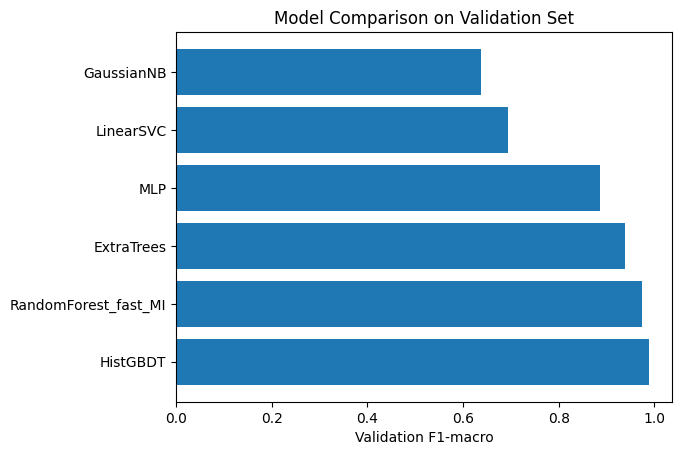

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(df["model"], df["val_f1_macro"])
plt.xlabel("Validation F1-macro")
plt.title("Model Comparison on Validation Set")
plt.show()

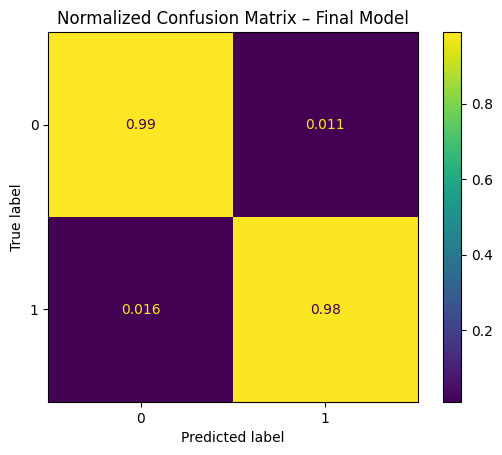

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true"
)
plt.title("Normalized Confusion Matrix – Final Model")
plt.show()


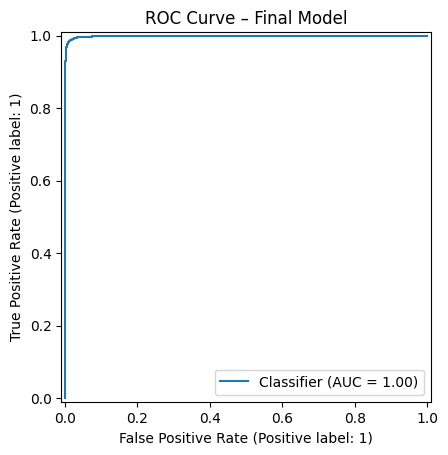

In [24]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve – Final Model")
plt.show()


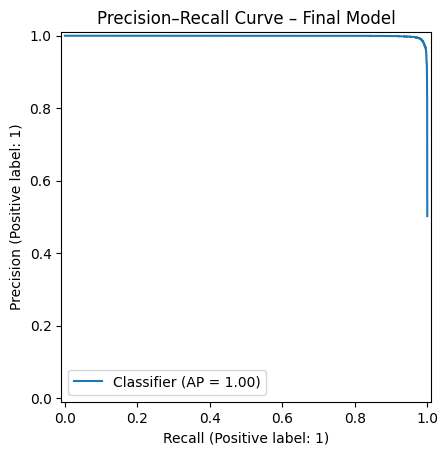

In [25]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("Precision–Recall Curve – Final Model")
plt.show()


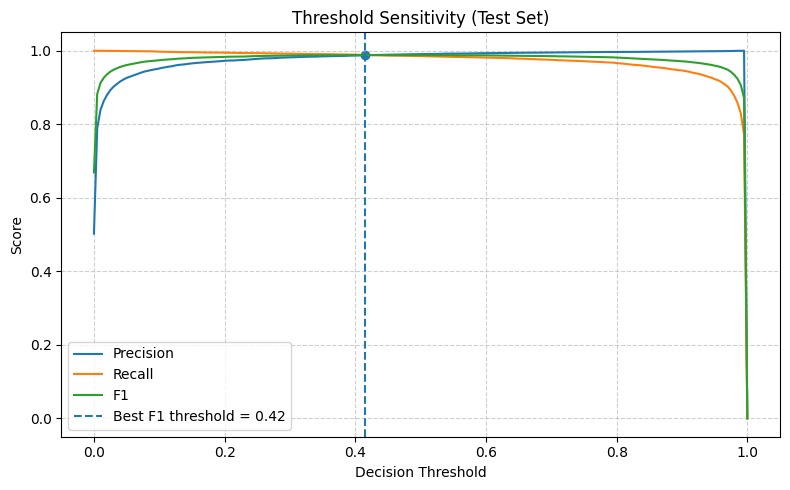

Best threshold for F1: 0.415 | Best F1: 0.9883


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score


model = best_estimators[best_name]


# Getting predicted probabilities for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Sweep thresholds
thresholds = np.linspace(0.0, 1.0, 201)

precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)

best_idx = np.argmax(f1s)
best_t = thresholds[best_idx]
best_f1 = f1s[best_idx]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")

plt.axvline(best_t, linestyle="--", label=f"Best F1 threshold = {best_t:.2f}")
plt.scatter([best_t], [best_f1])

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity (Test Set)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold for F1: {best_t:.3f} | Best F1: {best_f1:.4f}")


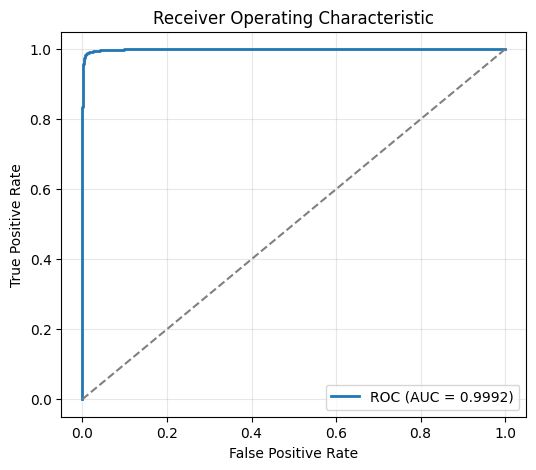

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2,
         label=f"ROC (AUC = {roc_auc_score(y_test, y_prob):.4f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

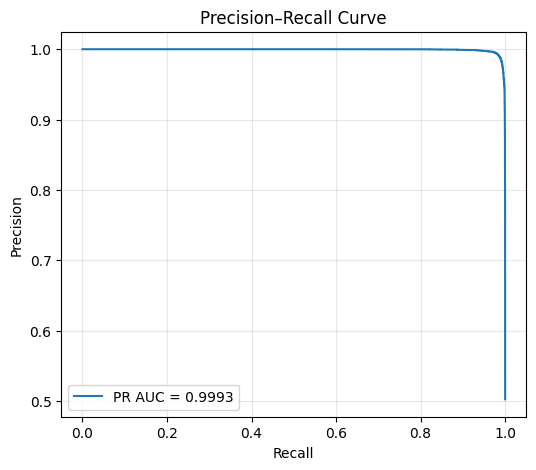

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

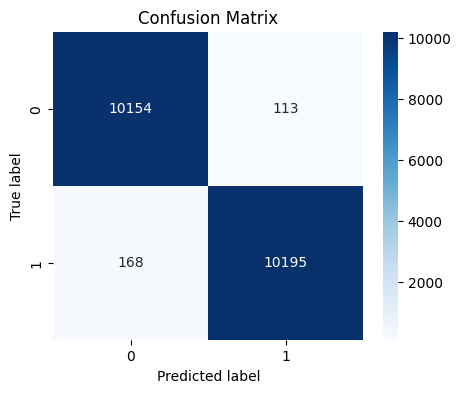

In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.show()

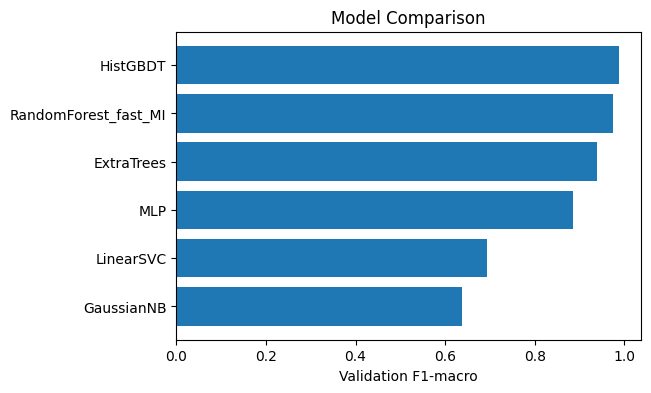

In [40]:
df_sorted = df.sort_values("val_f1_macro")

plt.figure(figsize=(6,4))
plt.barh(df_sorted["model"], df_sorted["val_f1_macro"])

plt.xlabel("Validation F1-macro")
plt.title("Model Comparison")

plt.show()

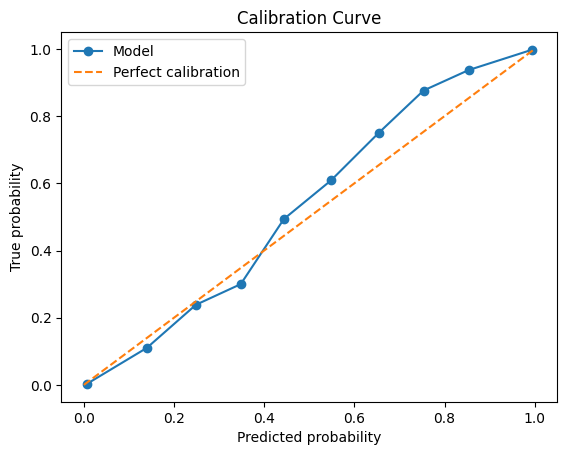

In [41]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1], [0,1], "--", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")

plt.legend()
plt.show()

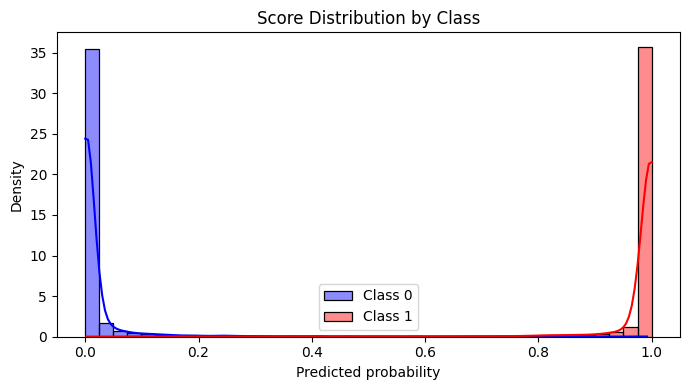

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

sns.histplot(
    y_prob[y_test == 0],
    bins=40,
    stat="density",
    color="blue",
    label="Class 0",
    alpha=0.45,
    kde=True
)

sns.histplot(
    y_prob[y_test == 1],
    bins=40,
    stat="density",
    color="red",
    label="Class 1",
    alpha=0.45,
    kde=True
)

plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("Score Distribution by Class")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
import numpy as np

# number of windows used in preprocessing
N_WINDOWS = 15

# the 34 features extracted per window
base_feature_names = [
    "Min",
    "Max",
    "Variance",
    "Skewness",
    "Kurtosis",
    "IQR",
    "HjorthMobility",
    "HjorthComplexity",
    "HurstExponent",
    "WaveletEntropy",
    "LogWaveletEntropy",
    "RMS",
    "ImpulseFactor",
    "MarginFactor",
    "ShapeFactor",
    "CrestFactor",
    "FreqCenter",
    "FreqRMS",
    "FreqSpread",
    "WhiteNoiseSimilarity",
    "BlueNoiseSimilarity",
    "BrownNoiseSimilarity",
    "PinkNoiseSimilarity",
    "PurpleNoiseSimilarity",
    "WD1_Min",
    "WD1_Max",
    "WD1_Mean",
    "WD4_Min",
    "WD4_Max",
    "WD4_Mean",
    "WD8_Min",
    "WD8_Max",
    "WD8_Mean",
    "Mean"
]

In [52]:
feature_names = []

for w in range(1, N_WINDOWS + 1):
    for f in base_feature_names:
        feature_names.append(f"Window{w}_{f}")

feature_names = np.array(feature_names)

print("Total features:", len(feature_names))

Total features: 510


In [53]:
print("X_test features:", X_test.shape[1])

X_test features: 510


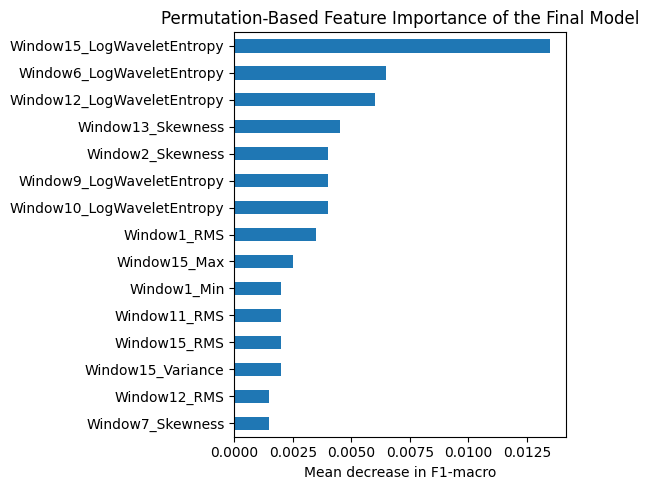

In [55]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

best_model = best_estimators[best_name]

# much smaller subset for speed
X_small = X_test[:1000]
y_small = y_test[:1000]

result = permutation_importance(
    best_model,
    X_small,
    y_small,
    n_repeats=2,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

importances = result.importances_mean
feature_names = feature_names

fi = pd.Series(importances, index=feature_names)
fi = fi.sort_values(ascending=False).head(15)

plt.figure(figsize=(6,5))
fi.sort_values().plot(kind="barh")
plt.title("Permutation-Based Feature Importance of the Final Model")
plt.xlabel("Mean decrease in F1-macro")
plt.tight_layout()
plt.show()